<a href="https://colab.research.google.com/github/19mddill/Deep_Learning_Notebooks/blob/main/ANN_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt

In [ ]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)","petal width (cm)"]].values
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X,y)


Perceptron(random_state=42)

In [ ]:
X_new = [[2,.5],[3,1]]
y_pred = per_clf.predict(X_new)
y_pred

array([ True, False])

w1: 5.800, w2: -16.700, b: -7.000
n_iter_ (iterations actually run): 9
Training accuracy: 0.653
Misclassified points: 52 out of 150

Saved plot.


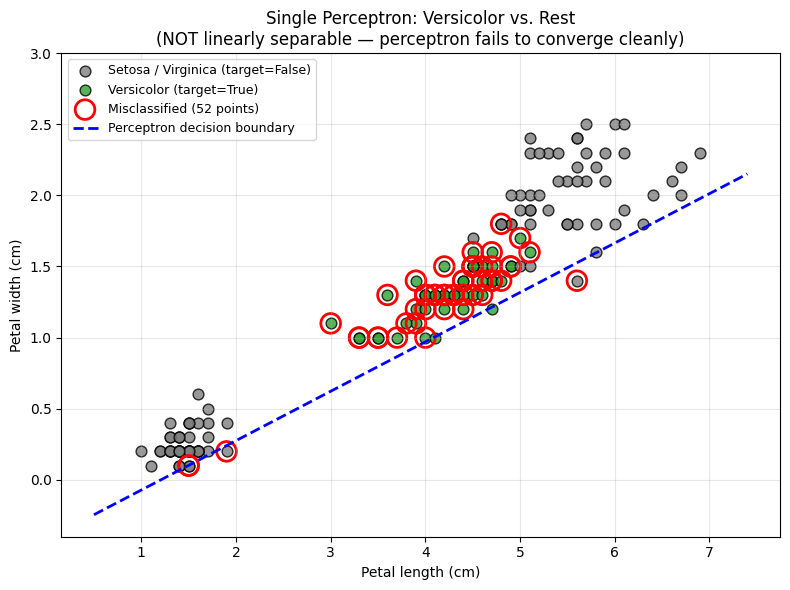

In [ ]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 1)   # Versicolor vs rest

per_clf = Perceptron(random_state=42, max_iter=1000)
per_clf.fit(X, y)

w1, w2 = per_clf.coef_[0]
b = per_clf.intercept_[0]

print(f"w1: {w1:.3f}, w2: {w2:.3f}, b: {b:.3f}")
print(f"n_iter_ (iterations actually run): {per_clf.n_iter_}")

preds = per_clf.predict(X)
n_errors = np.sum(preds != y)
print(f"Training accuracy: {(preds == y).mean():.3f}")
print(f"Misclassified points: {n_errors} out of {len(y)}")

x1_range = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
x2_boundary = -(w1 * x1_range + b) / w2

plt.figure(figsize=(8, 6))

for i, name in enumerate(iris.target_names):
    mask = (iris.target == i)
    color = '#2ca02c' if i == 1 else '#7f7f7f'
    label = 'Versicolor (target=True)' if i == 1 else ('Setosa / Virginica (target=False)' if i == 0 else None)
    plt.scatter(X[mask, 0], X[mask, 1], c=color, label=label, edgecolor='k', s=60, alpha=0.8)

misclassified = preds != y
plt.scatter(X[misclassified, 0], X[misclassified, 1], facecolors='none',
            edgecolors='red', s=200, linewidths=2, label=f'Misclassified ({n_errors} points)')

plt.plot(x1_range, x2_boundary, 'b--', linewidth=2, label='Perceptron decision boundary')

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Single Perceptron: Versicolor vs. Rest\n(NOT linearly separable — perceptron fails to converge cleanly)')
plt.legend(loc='upper left', fontsize=9)
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
print("\nSaved plot.")

w1 (petal length weight): -1.400
w2 (petal width weight):  -2.200
b (bias):                 4.000

Saved plot.


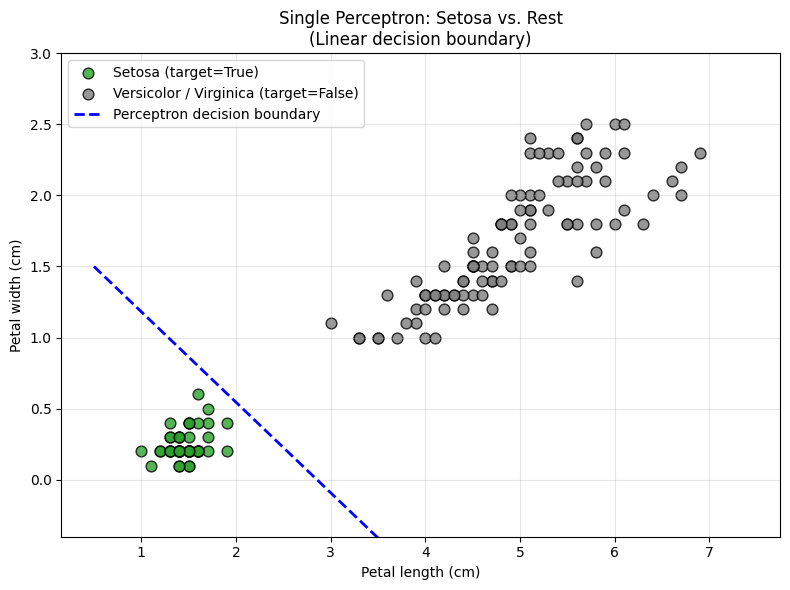

In [ ]:


iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)


w1, w2 = per_clf.coef_[0]
b = per_clf.intercept_[0]

print(f"w1 (petal length weight): {w1:.3f}")
print(f"w2 (petal width weight):  {w2:.3f}")
print(f"b (bias):                 {b:.3f}")


x1_range = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
x2_boundary = -(w1 * x1_range + b) / w2

plt.figure(figsize=(8, 6))


colors = ['#2ca02c', '#7f7f7f', '#7f7f7f']  # Setosa green, other two grey
labels = ['Setosa (target)', 'Versicolor/Virginica', None]

for i, name in enumerate(iris.target_names):
    mask = (iris.target == i)
    color = colors[i]
    label = 'Setosa (target=True)' if i == 0 else ('Versicolor / Virginica (target=False)' if i == 1 else None)
    plt.scatter(X[mask, 0], X[mask, 1], c=color, label=label, edgecolor='k', s=60, alpha=0.8)


plt.plot(x1_range, x2_boundary, 'b--', linewidth=2, label='Perceptron decision boundary')

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Single Perceptron: Setosa vs. Rest\n(Linear decision boundary)')
plt.legend(loc='upper left')
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
print("\nSaved plot.")
